# 00 - Existing hex_plot() function

This notebook tests the existing hex_plot() function in order to take it as a base for further visualization functions.

## __Import libraries__

In [1]:
from pathlib import Path

current_path = Path().resolve()

for parent in current_path.parents:
    if parent.name == "odc":
        project_root = parent
        break

print(project_root)

/home/jovyan/odc


In [2]:
import os
import sys

import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

module_path = os.path.abspath(os.path.join(project_root))
if module_path not in sys.path:
    sys.path.append(module_path)
    print("Path found")
    import odc

Path found


## __Config notebook__

In [3]:
res = 8
city = 'Aguascalientes'

## __Load data__

In [4]:
# Load data test
data_schema = 'prox_analysis'
data_table = f'proximityanalysis_v2_23_mzaageb_hex'
# Load city's hexs filtering for urban areas if required
query = f"SELECT * FROM {data_schema}.{data_table} WHERE \"city\" = '{city}\' AND \"res\" = '{res}\'"
data_gdf = odc.gdf_from_query(query, geometry_col='geometry')

# Show
print(data_gdf.crs)
print(data_gdf.shape)
data_gdf.head(2)

epsg:4326
(326, 69)


,hex_id,res,geometry,max_escuelas,max_preescolar,max_primaria,max_secundaria,max_servicios comunitarios,max_salud,max_guarderías,...,pobmas,p_0a5,p_6a11,p_12a17,p_18a24,p_25a59,p_60ymas,pcon_disc,dens_pob_ha,city
0,88498eac99fffff,8,"POLYGON ((-102.32395 21.82834, -102.31936 21.8...",38.240612,20.525927,31.562086,38.240612,39.439325,39.439325,33.827941,...,1216.74710,288.002890,248.37106,185.866275,173.77722,1432.567644,99.437836,27.819645,28.114145,Aguascalientes
1,884988d947fffff,8,"POLYGON ((-102.33664 21.85872, -102.33205 21.8...",36.404626,16.123503,23.844778,36.404626,50.537748,50.537748,25.462228,...,621.50946,63.252146,81.49846,148.321590,155.81941,606.319750,175.803940,40.546770,14.270372,Aguascalientes


In [5]:
# Download area of interest (aoi)
print('--- Downloading area of interest.')
metro_schema = 'metropolis'
metro_table = 'metro_gdf_2020'
query = f"SELECT * FROM {metro_schema}.{metro_table} WHERE \"city\" LIKE \'{city}\'"
mun_gdf = odc.gdf_from_query(query, geometry_col='geometry')
mun_gdf = mun_gdf.set_crs("EPSG:4326")
aoi = mun_gdf.dissolve()

# Download Network (G, nodes, edges)
print('--- Downloading network.')
network_schema = 'osmnx'
nodes_table = 'nodes_osmnx_23_point'
edges_table = 'edges_speed_23_line'
G, nodes_gdf, edges_gdf = odc.graph_from_hippo(aoi, schema=network_schema, edges_folder=edges_table, nodes_folder=nodes_table)

# Show
print(edges_gdf.crs)
print(edges_gdf.shape)
edges_gdf.head(2)

--- Downloading area of interest.
--- Downloading network.
EPSG:4326
(128150, 19)


osmid  oneway                   name  \
u          v          key                                             
8414611560 1729024510 0    906116849   False  Boulevard Guadalupano   
           2304455693 0    906116850    True  Boulevard Guadalupano   

                             highway  length  \
u          v          key                      
8414611560 1729024510 0    secondary  53.013   
           2304455693 0    secondary  11.792   

                                                                    geometry  \
u          v          key                                                      
8414611560 1729024510 0    LINESTRING (-102.25354 21.91028, -102.25343 21...   
           2304455693 0    LINESTRING (-102.25354 21.91028, -102.25353 21...   

                           grade  grade_abs lanes bridge maxspeed     ref  \
u          v          key                                                   
8414611560 1729024510 0   -0.038      0.038     3   None     None  AGS 60   
           2304455693 0    0.000      0.000     3   None       40  AGS 60   

                          access junction service tunnel width  walkspeed  \
u          v          key                                                   
8414611560 1729024510 0     None     None    None   None  None    3.50186   
           2304455693 0     None     None    None   None  None    4.00000   

                           time_min  
u          v          key            
8414611560 1729024510 0    0.908311  
           2304455693 0    0.176880

## __Visualization__

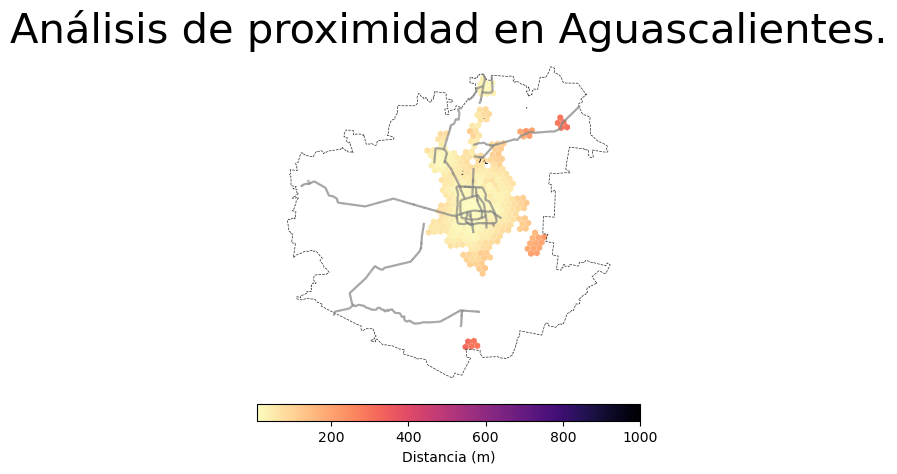

In [6]:
fig,ax = plt.subplots()

odc.hex_plot(ax=ax,
             gdf_data = data_gdf,
             gdf_boundary = aoi,
             gdf_edges = edges_gdf,
             column = 'max_time', 
             title = f'Análisis de proximidad en {city}.',
             save_png = False,
save_pdf = False,
show = True,
name = 'plot',
dpi = 300,
transparent = True, 
close_figure = False)